### Summary: Data Exploration

- Only one instrument (AAPL) - cross-asset OFI not possible

- Sequnece number missing - presumably book state is not changing in between - so we are good. But possible inconsistencies: 
    - Index 7 - book levels not changing properly
    - Index 267 - random new level
    - Index 962 - incorrect depth
    - Index 2426 - new level added at given depth, this one added to one further down

- T action - Trade event - probably IOC

- N side - Order did not go through

- T event followed by C event with the same sequence number if an entire order is removed, i.e., count decreases

- 3 instances of A-N - should be A-A

- Removed events with no order book change from ofi calculations

- Very small data - just 5000 rows - not getting as good a results for correlations, regressions, R2 as in the paper.

- Integrated OFI (PC1) explaining just 33% of variance (compared to 89% in the paper)

- Getting best in-sample adj-R2 for multi-level model and worst for integreted ofi model (see below).

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv('first_25000_rows.csv', parse_dates=["ts_event"])
df

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21 11:54:29.221064336+00:00,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21 11:54:29.223769812+00:00,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21 11:54:29.225030400+00:00,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21 11:54:29.712434212+00:00,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21 11:54:29.764673165+00:00,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2024-10-21T13:04:16.583694069Z,2024-10-21 13:04:16.583527688+00:00,10,2,38,A,B,2,233.46,200,...,105,1,2,233.25,234.50,55,63,2,4,AAPL
4996,2024-10-21T13:04:17.976627074Z,2024-10-21 13:04:17.976461017+00:00,10,2,38,A,A,1,233.69,200,...,105,1,2,233.25,234.50,55,63,2,4,AAPL
4997,2024-10-21T13:04:20.085804687Z,2024-10-21 13:04:20.085638629+00:00,10,2,38,C,B,2,233.46,200,...,105,2,2,233.24,234.50,1,63,1,4,AAPL
4998,2024-10-21T13:04:20.085817362Z,2024-10-21 13:04:20.085651109+00:00,10,2,38,A,B,3,233.44,200,...,105,1,2,233.25,234.50,55,63,2,4,AAPL


In [3]:
df.columns

Index(['ts_recv', 'ts_event', 'rtype', 'publisher_id', 'instrument_id',
       'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta',
       'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00',
       'bid_ct_00', 'ask_ct_00', 'bid_px_01', 'ask_px_01', 'bid_sz_01',
       'ask_sz_01', 'bid_ct_01', 'ask_ct_01', 'bid_px_02', 'ask_px_02',
       'bid_sz_02', 'ask_sz_02', 'bid_ct_02', 'ask_ct_02', 'bid_px_03',
       'ask_px_03', 'bid_sz_03', 'ask_sz_03', 'bid_ct_03', 'ask_ct_03',
       'bid_px_04', 'ask_px_04', 'bid_sz_04', 'ask_sz_04', 'bid_ct_04',
       'ask_ct_04', 'bid_px_05', 'ask_px_05', 'bid_sz_05', 'ask_sz_05',
       'bid_ct_05', 'ask_ct_05', 'bid_px_06', 'ask_px_06', 'bid_sz_06',
       'ask_sz_06', 'bid_ct_06', 'ask_ct_06', 'bid_px_07', 'ask_px_07',
       'bid_sz_07', 'ask_sz_07', 'bid_ct_07', 'ask_ct_07', 'bid_px_08',
       'ask_px_08', 'bid_sz_08', 'ask_sz_08', 'bid_ct_08', 'ask_ct_08',
       'bid_px_09', 'ask_px_09', 'bid_sz_09', 'ask_sz_09', 'bi

In [4]:
df.shape

(5000, 74)

In [5]:
df.describe()

,rtype,publisher_id,instrument_id,depth,price,size,flags,ts_in_delta,sequence,bid_px_00,...,bid_sz_08,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09
count,5000.0,5000.0,5000.0,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,...,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,10.0,2.0,38.0,1.407600,233.806564,153.169200,128.031600,1.707528e+05,1.344078e+07,233.755936,...,89.929600,259.928600,1.38500,1.886200,233.364424,234.464900,68.382200,185.662200,1.434200,2.097200
std,0.0,0.0,0.0,1.455158,0.170972,129.459973,15.802283,5.433114e+04,1.254097e+06,0.112182,...,135.718278,450.030627,0.50242,1.341943,0.076242,0.232418,89.704575,344.015312,0.504104,1.460198
min,10.0,2.0,38.0,0.000000,232.600000,1.000000,0.000000,1.655530e+05,1.140585e+07,233.500000,...,1.000000,1.000000,1.00000,1.000000,233.200000,233.680000,1.000000,1.000000,1.000000,1.000000
25%,10.0,2.0,38.0,0.000000,233.690000,29.000000,130.000000,1.661180e+05,1.235669e+07,233.700000,...,15.000000,60.000000,1.00000,1.000000,233.310000,234.250000,15.000000,5.000000,1.000000,1.000000
50%,10.0,2.0,38.0,1.000000,233.800000,200.000000,130.000000,1.663280e+05,1.327258e+07,233.760000,...,100.000000,105.000000,1.00000,1.000000,233.390000,234.430000,55.000000,63.000000,1.000000,1.000000
75%,10.0,2.0,38.0,2.000000,233.920000,200.000000,130.000000,1.666125e+05,1.456848e+07,233.850000,...,110.000000,400.000000,2.00000,2.000000,233.400000,234.590000,110.000000,105.000000,2.000000,4.000000
max,10.0,2.0,38.0,9.000000,235.000000,1200.000000,130.000000,2.215188e+06,1.556924e+07,233.980000,...,1207.000000,2000.000000,3.00000,7.000000,233.660000,235.030000,1109.000000,2000.000000,3.000000,7.000000


In [6]:
for col in ['symbol', 'instrument_id', 'action', 'side', 'flags', 'sequence']:
    print(df[col].value_counts())
    print()

symbol
AAPL    5000
Name: count, dtype: int64

instrument_id
38    5000
Name: count, dtype: int64

action
A    2695
C    2019
T     286
Name: count, dtype: int64

side
B    2497
A    2383
N     120
Name: count, dtype: int64

flags
130    4879
0        75
128      46
Name: count, dtype: int64

sequence
11649200    2
12974807    2
14226814    2
15427490    2
14278515    2
           ..
12633058    1
12633057    1
12633055    1
12633054    1
15569241    1
Name: count, Length: 4880, dtype: int64



In [7]:
df.groupby(['action','side','flags']).groups.keys()

dict_keys([('A', 'A', 128), ('A', 'A', 130), ('A', 'B', 128), ('A', 'B', 130), ('A', 'N', 130), ('C', 'A', 128), ('C', 'A', 130), ('C', 'B', 128), ('C', 'B', 130), ('C', 'N', 130), ('T', 'A', 0), ('T', 'A', 128), ('T', 'A', 130), ('T', 'B', 0), ('T', 'B', 128), ('T', 'B', 130), ('T', 'N', 0), ('T', 'N', 130)])

In [8]:
levels = list(range(10))
lob_columns = [f"{side}_{attr}_{str(i).zfill(2)}"
               for attr in ['px', 'sz', 'ct']
               for side in ['bid', 'ask']
               for i in levels]
lob_diff = df[lob_columns].diff().abs().sum(axis=1)
change_mask = lob_diff > 0
change_mask[0] = True
df_filtered = df[change_mask].reset_index(drop=True)
df_filtered.shape

(4760, 74)

In [9]:
levels = list(range(10))

of_bid = []
of_ask = []

for m in levels:
    px_b = df_filtered[f"bid_px_{str(m).zfill(2)}"].values
    px_b_prev = np.roll(px_b, 1)
    sz_b = df_filtered[f"bid_sz_{str(m).zfill(2)}"].values
    sz_b_prev = np.roll(sz_b, 1)

    px_a = df_filtered[f"ask_px_{str(m).zfill(2)}"].values
    px_a_prev = np.roll(px_a, 1)
    sz_a = df_filtered[f"ask_sz_{str(m).zfill(2)}"].values
    sz_a_prev = np.roll(sz_a, 1)

    of_b = np.where(px_b > px_b_prev, sz_b,
           np.where(px_b == px_b_prev, sz_b - sz_b_prev,
           -sz_b_prev))
    of_b[0] = 0  # first row invalid
    of_bid.append(of_b)

    of_a = np.where(px_a > px_a_prev, -sz_a,
           np.where(px_a == px_a_prev, sz_a - sz_a_prev,
           sz_a_prev))
    of_a[0] = 0
    of_ask.append(of_a)

of_bid = np.stack(of_bid, axis=1)
of_ask = np.stack(of_ask, axis=1)
ofi_per_level = of_bid - of_ask

In [10]:
ofi_per_level.shape

(4760, 10)

In [11]:
df_filtered["minute"] = df_filtered["ts_event"].dt.floor("1min")
ofi_df = pd.DataFrame(ofi_per_level, columns=[f"OFI_{m}" for m in levels])
ofi_df["minute"] = df_filtered["minute"]
ofi_agg = ofi_df.groupby("minute").sum()
ofi_agg

,OFI_0,OFI_1,OFI_2,OFI_3,OFI_4,OFI_5,OFI_6,OFI_7,OFI_8,OFI_9
minute,,,,,,,,,,
2024-10-21 11:54:00+00:00,-195,600,10,-30,25,400,44,155,400,1
2024-10-21 11:55:00+00:00,-1115,781,1370,27,11,-84,-10,-110,-100,-55
2024-10-21 11:56:00+00:00,199,0,1200,0,0,0,0,1,0,0
2024-10-21 11:57:00+00:00,500,592,50,4,-840,-118,-234,-88,-454,-346
2024-10-21 11:58:00+00:00,477,880,572,432,226,-412,256,88,544,291
...,...,...,...,...,...,...,...,...,...,...
2024-10-21 13:00:00+00:00,-1093,130,1530,-507,-1407,-1,-505,85,-124,0
2024-10-21 13:01:00+00:00,-1623,-1183,-1661,-799,-919,-687,171,-14,500,590
2024-10-21 13:02:00+00:00,-6073,-5749,-4202,-1362,-1770,-2613,-1311,-556,-889,-979


In [12]:
rets = df_filtered[["minute","bid_px_00","ask_px_00"]].groupby("minute").agg(['first','last'])
rets['open_mid'] = (rets['bid_px_00']['first'] + rets['ask_px_00']['first']) / 2
rets['close_mid'] = (rets['bid_px_00']['last'] + rets['ask_px_00']['last']) / 2
ret = np.log(rets['close_mid']/rets['open_mid'])

In [13]:
q_m_vals = []
for m in levels:
    sz_b = df_filtered[f"bid_sz_{str(m).zfill(2)}"]
    sz_a = df_filtered[f"ask_sz_{str(m).zfill(2)}"]
    q_m_vals.append((sz_b + sz_a) / 2)
q_matrix = pd.concat(q_m_vals, axis=1)
q_matrix["minute"] = df_filtered["minute"]
Q_M = q_matrix.groupby("minute").mean().mean(axis=1)
Q_M

minute
2024-10-21 11:54:00+00:00    107.909259
2024-10-21 11:55:00+00:00    108.616327
2024-10-21 11:56:00+00:00    109.580556
2024-10-21 11:57:00+00:00    112.887324
2024-10-21 11:58:00+00:00    114.392857
                                ...    
2024-10-21 13:00:00+00:00    184.290789
2024-10-21 13:01:00+00:00    187.772650
2024-10-21 13:02:00+00:00    134.482364
2024-10-21 13:03:00+00:00    112.483468
2024-10-21 13:04:00+00:00    112.194000
Length: 71, dtype: float64

In [14]:
normalized_ofis = ofi_agg[[f"OFI_{m}" for m in levels]].div(Q_M, axis=0)
normalized_ofis

,OFI_0,OFI_1,OFI_2,OFI_3,OFI_4,OFI_5,OFI_6,OFI_7,OFI_8,OFI_9
minute,,,,,,,,,,
2024-10-21 11:54:00+00:00,-1.807074,5.560227,0.092670,-0.278011,0.231676,3.706818,0.407750,1.436392,3.706818,0.009267
2024-10-21 11:55:00+00:00,-10.265492,7.190448,12.613205,0.248581,0.101274,-0.773364,-0.092067,-1.012739,-0.920672,-0.506370
2024-10-21 11:56:00+00:00,1.816016,0.000000,10.950848,0.000000,0.000000,0.000000,0.000000,0.009126,0.000000,0.000000
2024-10-21 11:57:00+00:00,4.429195,5.244167,0.442920,0.035434,-7.441048,-1.045290,-2.072863,-0.779538,-4.021709,-3.065003
2024-10-21 11:58:00+00:00,4.169841,7.692788,5.000312,3.776460,1.975648,-3.601623,2.237902,0.769279,4.755542,2.543865
...,...,...,...,...,...,...,...,...,...,...
2024-10-21 13:00:00+00:00,-5.930844,0.705407,8.302097,-2.751087,-7.634673,-0.005426,-2.740235,0.461228,-0.672850,0.000000
2024-10-21 13:01:00+00:00,-8.643431,-6.300172,-8.845804,-4.255146,-4.894217,-3.658680,0.910676,-0.074558,2.662795,3.142098
2024-10-21 13:02:00+00:00,-45.158338,-42.749100,-31.245733,-10.127722,-13.161577,-19.430057,-9.748490,-4.134371,-6.610532,-7.279765


In [15]:
pca = PCA(n_components=1)
pca.fit(normalized_ofis.fillna(0))

PCA(n_components=1)

In [16]:
pca.components_.shape

(1, 10)

In [17]:
pca.explained_variance_ratio_

array([0.52485081])

In [18]:
integrated_ofi_raw = np.dot(np.array(normalized_ofis), pca.components_[0].T)
w1_l1 = np.sum(np.abs(pca.components_[0]))
normalized_ofis["Integrated_OFI"] = integrated_ofi_raw.flatten() / w1_l1
ofi_features = normalized_ofis[["Integrated_OFI"] + [f"OFI_{m}" for m in levels]]
ofi_features.rename(columns={"OFI_0": "Best_level_OFI"}, inplace=True)
ofi_features

,Integrated_OFI,Best_level_OFI,OFI_1,OFI_2,OFI_3,OFI_4,OFI_5,OFI_6,OFI_7,OFI_8,OFI_9
minute,,,,,,,,,,,
2024-10-21 11:54:00+00:00,1.429853,-1.807074,5.560227,0.092670,-0.278011,0.231676,3.706818,0.407750,1.436392,3.706818,0.009267
2024-10-21 11:55:00+00:00,1.611627,-10.265492,7.190448,12.613205,0.248581,0.101274,-0.773364,-0.092067,-1.012739,-0.920672,-0.506370
2024-10-21 11:56:00+00:00,2.184182,1.816016,0.000000,10.950848,0.000000,0.000000,0.000000,0.000000,0.009126,0.000000,0.000000
2024-10-21 11:57:00+00:00,0.737625,4.429195,5.244167,0.442920,0.035434,-7.441048,-1.045290,-2.072863,-0.779538,-4.021709,-3.065003
2024-10-21 11:58:00+00:00,3.823759,4.169841,7.692788,5.000312,3.776460,1.975648,-3.601623,2.237902,0.769279,4.755542,2.543865
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-21 13:00:00+00:00,-0.577597,-5.930844,0.705407,8.302097,-2.751087,-7.634673,-0.005426,-2.740235,0.461228,-0.672850,0.000000
2024-10-21 13:01:00+00:00,-5.118750,-8.643431,-6.300172,-8.845804,-4.255146,-4.894217,-3.658680,0.910676,-0.074558,2.662795,3.142098
2024-10-21 13:02:00+00:00,-27.416626,-45.158338,-42.749100,-31.245733,-10.127722,-13.161577,-19.430057,-9.748490,-4.134371,-6.610532,-7.279765


In [19]:
ofi_features['ret'] = ret

In [20]:
ofi_features.describe()

,Integrated_OFI,Best_level_OFI,OFI_1,OFI_2,OFI_3,OFI_4,OFI_5,OFI_6,OFI_7,OFI_8,OFI_9,ret
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,-0.208109,-1.250814,-1.771600,2.217227,0.884101,-0.381372,-0.372905,-0.094750,0.133863,0.172046,0.250770,-0.000007
std,4.031375,6.288327,7.576463,6.760615,4.908018,4.196362,3.333387,3.074705,2.828803,2.574016,3.031716,0.000247
min,-27.416626,-45.158338,-42.749100,-31.245733,-18.083572,-16.190553,-19.430057,-9.894563,-7.331520,-7.809275,-7.813177,-0.000920
25%,-1.365021,-2.631374,-4.850357,-0.209220,-1.339328,-2.143534,-1.060762,-1.486115,-1.151109,-0.623501,-0.573155,-0.000150
50%,0.517658,0.000000,-1.707750,1.860121,0.035434,-0.005011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000021
75%,1.700147,1.236508,2.018941,6.463849,3.719561,1.874114,0.722342,0.813477,1.803334,0.656733,0.768678,0.000128
max,4.687050,6.325448,14.415504,13.951051,13.120480,9.837903,6.312039,8.987987,8.370242,7.854806,9.871355,0.000449


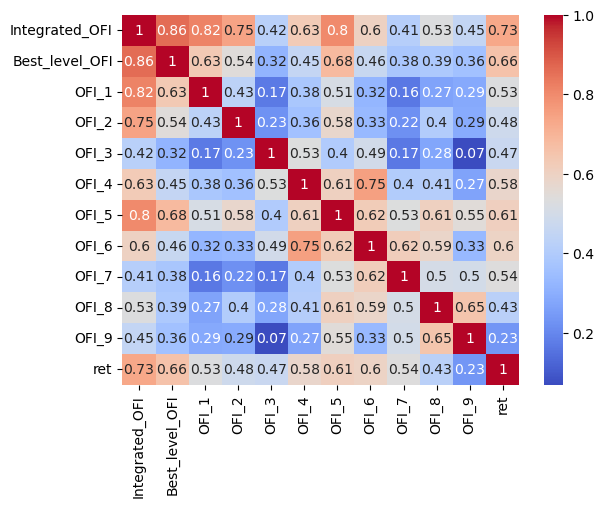

In [21]:
sns.heatmap(ofi_features.corr(), annot=True, cmap='coolwarm');

In [22]:
# Best level OFI model

res = {}
model = smf.ols('ret ~ Best_level_OFI', data=ofi_features).fit()
res['best_level'] = model.rsquared_adj
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     52.42
Date:                Fri, 02 May 2025   Prob (F-statistic):           4.88e-10
Time:                        23:39:32   Log-Likelihood:                 509.57
No. Observations:                  71   AIC:                            -1015.
Df Residuals:                      69   BIC:                            -1011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.534e-05   2.27e-05      1.

In [23]:
# Integrated OFI model

model = smf.ols('ret ~ Integrated_OFI', data=ofi_features).fit()
res['integrated'] = model.rsquared_adj
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     79.76
Date:                Fri, 02 May 2025   Prob (F-statistic):           3.98e-13
Time:                        23:39:32   Log-Likelihood:                 516.78
No. Observations:                  71   AIC:                            -1030.
Df Residuals:                      69   BIC:                            -1025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       2.398e-06   2.01e-05      0.

In [24]:
# Multi-level model

a = list(ofi_features.columns)
a.remove('Integrated_OFI')
a.remove('ret')
model = smf.ols(f'ret ~ {' + '.join(a)}', data=ofi_features).fit()
res['multi_level'] = model.rsquared_adj
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     12.93
Date:                Fri, 02 May 2025   Prob (F-statistic):           1.15e-11
Time:                        23:39:34   Log-Likelihood:                 530.30
No. Observations:                  71   AIC:                            -1039.
Df Residuals:                      60   BIC:                            -1014.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       9.143e-07   2.21e-05      0.

In [25]:
print('Adjusted_R2')
pd.Series(res)

Adjusted_R2


best_level     0.423478
integrated     0.529455
multi_level    0.630224
dtype: float64